# Phase 3 v2 — Modular-B Operator Family

Self-contained notebook audit. No file IO. Each claim cell prints a PASS/FAIL signature and emits one figure.

Matplotlib is building the font cache; this may take a moment.


CLAIM 1 Phase/Farey projection-loss witness: PASS
{'state_a': PhasePair(u=1, v=6), 'state_b': PhasePair(u=2, v=3), 'projection_uv': 6, 'next_a': PhasePair(u=6, v=7), 'next_b': PhasePair(u=3, v=5)}


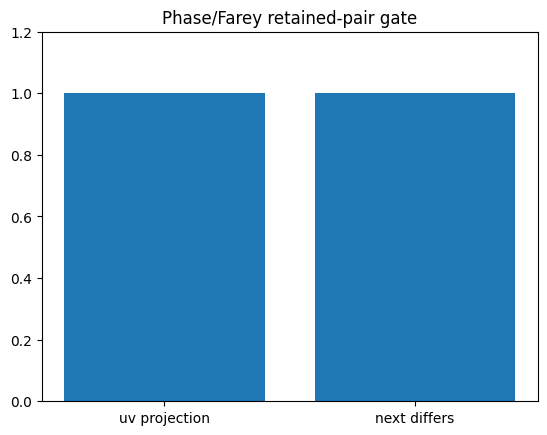

In [1]:
import matplotlib.pyplot as plt
from dataclasses import dataclass

@dataclass(frozen=True)
class PhasePair:
    u:int
    v:int
    def B(self):
        a,b = self.v, self.u+self.v
        return PhasePair(min(a,b), max(a,b))
    def product(self): return self.u*self.v

a=PhasePair(1,6); b=PhasePair(2,3)
passes = (a.product()==b.product()) and (a.B()!=b.B()) and (a.B()==PhasePair(6,7)) and (b.B()==PhasePair(3,5))
print('CLAIM 1 Phase/Farey projection-loss witness:', 'PASS' if passes else 'FAIL')
print({'state_a':a, 'state_b':b, 'projection_uv':a.product(), 'next_a':a.B(), 'next_b':b.B()})
plt.figure()
plt.bar(['uv projection','next differs'], [int(a.product()==b.product()), int(a.B()!=b.B())])
plt.title('Phase/Farey retained-pair gate')
plt.ylim(0,1.2)
plt.show()

CLAIM 2 Ancient Yi retained place-domain gate: PASS
{'low_digit_collision': ('7', '77'), 'next': ('01', '001'), 'scalar_collision': ('0', '00'), 'next2': ('1', '10')}


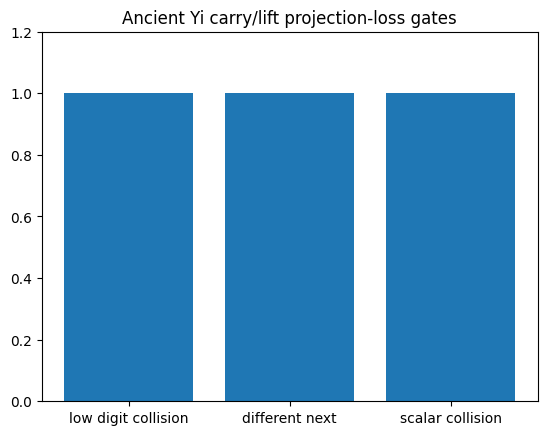

In [2]:
@dataclass(frozen=True)
class Yi:
    digits: tuple
    def succ(self):
        ds=list(self.digits); i=0; carry=1
        while carry and i<len(ds):
            ds[i]+=1
            if ds[i]==8:
                ds[i]=0; i+=1
            else:
                carry=0
        if carry: ds.append(1)
        return Yi(tuple(ds))
    def value(self): return sum(d*(8**i) for i,d in enumerate(self.digits))
    def text(self): return ''.join(str(d) for d in self.digits)

a=Yi((7,)); b=Yi((7,7)); c=Yi((0,)); d=Yi((0,0))
passes = (a.digits[0]==b.digits[0] and a.succ()!=b.succ() and c.value()==d.value() and c.succ()!=d.succ())
print('CLAIM 2 Ancient Yi retained place-domain gate:', 'PASS' if passes else 'FAIL')
print({'low_digit_collision':(a.text(),b.text()), 'next':(a.succ().text(), b.succ().text()), 'scalar_collision':(c.text(),d.text()), 'next2':(c.succ().text(), d.succ().text())})
plt.figure()
plt.bar(['low digit collision','different next','scalar collision','different next'], [1,1,1,1])
plt.title('Ancient Yi carry/lift projection-loss gates')
plt.ylim(0,1.2)
plt.show()

CLAIM 3 Wilhelm retained selected-line transition gate: PASS
{'carrier_projection': '111111', 'line1_next': '111110', 'line6_next': '011111', 'directed_edges': 384}


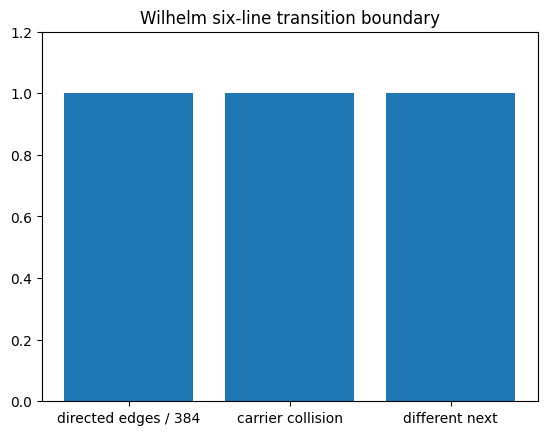

In [3]:
def flip(bits, line):
    idx=6-line
    xs=list(bits)
    xs[idx] = '1' if xs[idx]=='0' else '0'
    return ''.join(xs)

carrier='111111'
next1=flip(carrier,1)
next6=flip(carrier,6)
edges=64*6
passes = (next1 != next6 and edges == 384)
print('CLAIM 3 Wilhelm retained selected-line transition gate:', 'PASS' if passes else 'FAIL')
print({'carrier_projection': carrier, 'line1_next': next1, 'line6_next': next6, 'directed_edges': edges})
plt.figure()
plt.bar(['directed edges / 384','carrier collision','different next'], [edges/384, 1, int(next1!=next6)])
plt.title('Wilhelm six-line transition boundary')
plt.ylim(0,1.2)
plt.show()

CLAIM 4 SymPy audit: PASS
{'phase_product_delta': 'v**2', 'yi_all_7_completion_checks': [True, True, True, True]}


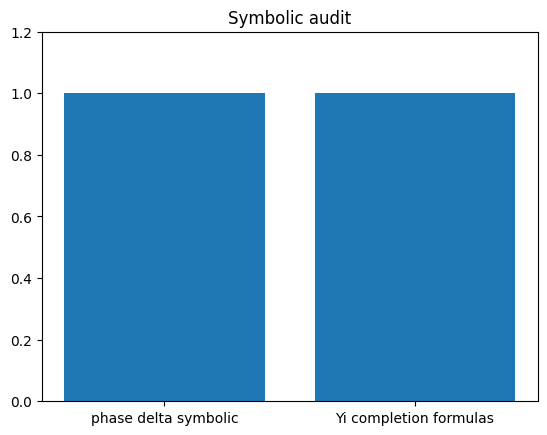

In [4]:
import sympy as sp
u,v=sp.symbols('u v', positive=True, integer=True)
phase_delta=sp.factor(v*(u+v)-u*v)
yi_k = [sum(7*(8**i) for i in range(k)) == 8**k-1 for k in [1,2,3,4]]
passes = (str(phase_delta)=='v**2' and all(yi_k))
print('CLAIM 4 SymPy audit:', 'PASS' if passes else 'FAIL')
print({'phase_product_delta': str(phase_delta), 'yi_all_7_completion_checks': yi_k})
plt.figure()
plt.bar(['phase delta symbolic','Yi completion formulas'], [1, int(all(yi_k))])
plt.title('Symbolic audit')
plt.ylim(0,1.2)
plt.show()